In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

In [ ]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/sohamglobal/datasets/refs/heads/main/amazon_india_returns.csv",
    parse_dates=["Order_Date", "Delivery_Date", "Return_Request_Date", "Refund_Date"],
)
print(df.shape)          # (rows, columns)


(300, 42)


In [ ]:
print(df.head())         # first 5 rows


   Return_ID             Order_ID Customer_ID Customer_Name  Age Age_Group  \
0  RET700001  408-4318855-8132648   CUST10022    Karan Bose   25     25-34   
1  RET700002  403-1727544-9748499   CUST10034   Pooja Yadav   26     25-34   
2  RET700003  408-3589751-2255409   CUST10027     Isha Gill   37     35-44   
3  RET700004  404-7893590-5431477   CUST10097  Madhuri Gill   34     25-34   
4  RET700005  404-8639213-4470657   CUST10073  Pranav Reddy   24     18-24   

   Gender Region           State       City  ...  Return_Type  \
0    Male   West  Madhya Pradesh     Indore  ...       Refund   
1  Female   West     Maharashtra       Pune  ...       Refund   
2  Female  South          Kerala      Kochi  ...       Refund   
3  Female   West         Gujarat  Ahmedabad  ...  Replacement   
4    Male   East           Bihar      Patna  ...       Refund   

  Product_Condition  Return_Pickup_Method            Return_Status  \
0         Defective       Doorstep Pickup                Completed   


In [ ]:
print(df.info())         # column types and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Return_ID               300 non-null    object        
 1   Order_ID                300 non-null    object        
 2   Customer_ID             300 non-null    object        
 3   Customer_Name           300 non-null    object        
 4   Age                     300 non-null    int64         
 5   Age_Group               300 non-null    object        
 6   Gender                  300 non-null    object        
 7   Region                  300 non-null    object        
 8   State                   300 non-null    object        
 9   City                    300 non-null    object        
 10  City_Tier               300 non-null    object        
 11  Prime_Member            300 non-null    object        
 12  Customer_Tenure_Years   300 non-null    int64     

In [ ]:
print(df.describe())     # summary stats for numeric columns

              Age  Customer_Tenure_Years       MRP_INR  Discount_Pct  \
count  300.000000             300.000000    300.000000    300.000000   
mean    30.813333               3.653333   3771.223333     25.400000   
min     18.000000               0.000000    250.000000      0.000000   
25%     25.000000               2.000000   1180.000000     10.000000   
50%     30.000000               3.000000   1975.000000     20.000000   
75%     36.250000               6.000000   3492.250000     40.000000   
max     61.000000               8.000000  49999.000000     60.000000   
std      8.197305               2.510144   6513.327560     16.915292   

       Selling_Price_INR    Quantity  Shipping_Fee_INR  Order_Value_INR  \
count         300.000000  300.000000        300.000000       300.000000   
mean         2740.560000    1.103333          2.000000      2850.673333   
min           124.000000    1.000000          0.000000       124.000000   
25%           837.250000    1.000000          0.000

In [ ]:
print(df['Category'].value_counts().head(5))

Category
Electronics               71
Fashion                   64
Home & Kitchen            45
Beauty & Personal Care    30
Sports & Fitness          27
Name: count, dtype: int64


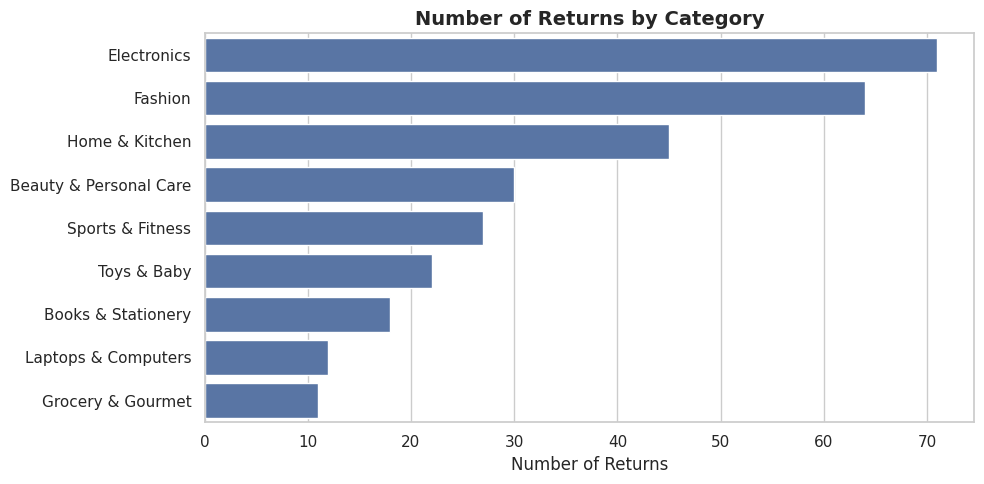

In [ ]:
# CHART 1: Returns by Category  (Bar chart)
# WHAT IT SHOWS: how many returns each product category has.
# WHY IT'S USEFUL: quickly tells you which categories are returned most.
order = df["Category"].value_counts().index
sns.countplot(data=df, y="Category", order=order)
plt.title("Number of Returns by Category")
plt.xlabel("Number of Returns")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
print(df['Return_Reason'].value_counts().head(5))

Return_Reason
Changed mind               54
Not as described           46
Poor quality               41
Damaged in transit         34
Defective / Not working    33
Name: count, dtype: int64


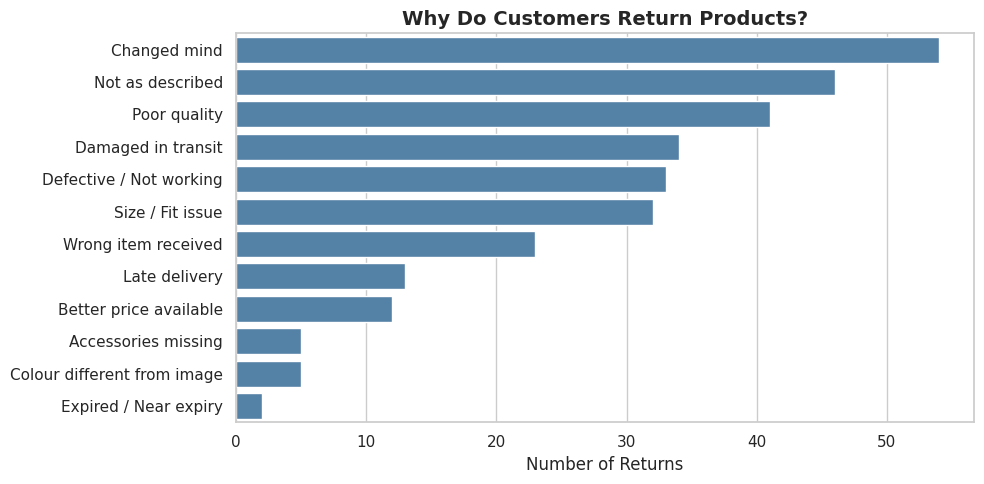

In [ ]:
# CHART 2: Top Return Reasons  (Bar chart)
# WHAT IT SHOWS: the most common reasons customers give for returning.
# WHY IT'S USEFUL: points to the root causes (quality, size, damage etc.).
order = df["Return_Reason"].value_counts().index
sns.countplot(data=df, y="Return_Reason", order=order, color="steelblue")
plt.title("Why Do Customers Return Products?")
plt.xlabel("Number of Returns")
plt.ylabel("")
plt.tight_layout()
plt.show()


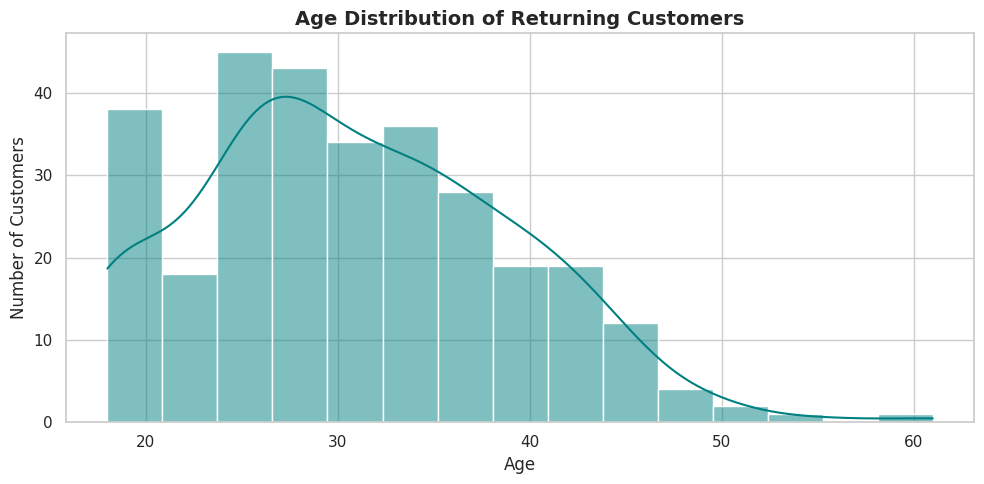

In [ ]:
# CHART 3: Age Distribution  (Histogram + KDE curve)
# WHAT IT SHOWS: how customer ages are spread out.
# The bars count customers per age band; the line smooths the shape.
sns.histplot(data=df, x="Age", bins=15, kde=True, color="teal")
plt.title("Age Distribution of Returning Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


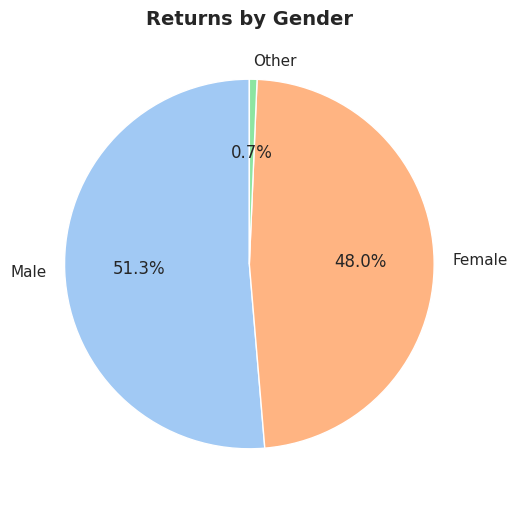

In [ ]:
# CHART 4: Gender Split  (Pie chart, matplotlib)
# WHAT IT SHOWS: each gender's share of total returns.
# TIP: use pie charts only when there are few slices (2-5).
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white"},
)
plt.title("Returns by Gender")
plt.show()


In [ ]:
print(df['Region'].value_counts())

Region
West     94
South    89
North    80
East     37
Name: count, dtype: int64


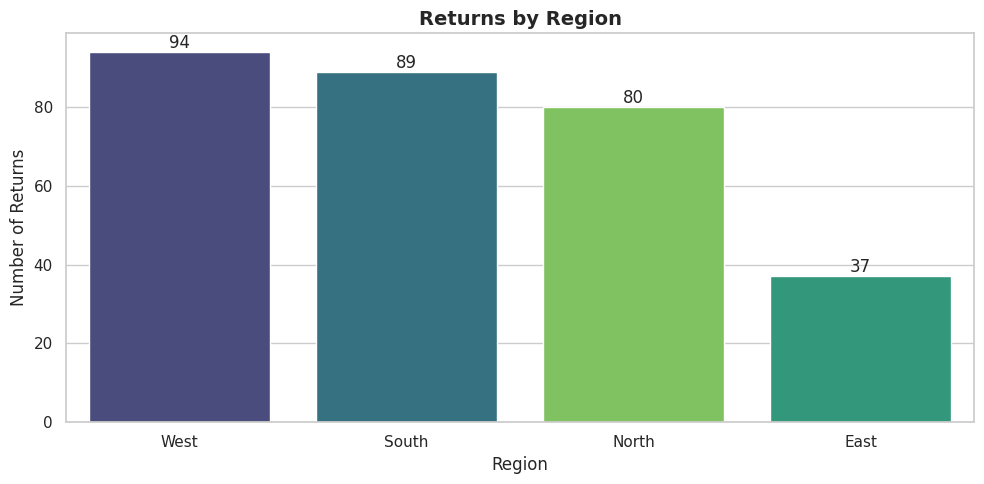

In [ ]:
# CHART 5: Returns by Region  (Column chart)
# WHAT IT SHOWS: which part of India (North/South/East/West) returns most.
order = df["Region"].value_counts().index
ax = sns.countplot(data=df, x="Region", order=order, palette="viridis", hue="Region", legend=False)
for container in ax.containers:
    ax.bar_label(container)          # print the count on top of each bar
plt.title("Returns by Region")
plt.xlabel("Region")
plt.ylabel("Number of Returns")
plt.tight_layout()
plt.show()


In [ ]:
print(df['Payment_Mode'].value_counts().head(7))

Payment_Mode
UPI                   81
Cash on Delivery      79
Credit Card           73
Debit Card            29
Net Banking           17
Amazon Pay Balance    14
Gift Card              7
Name: count, dtype: int64


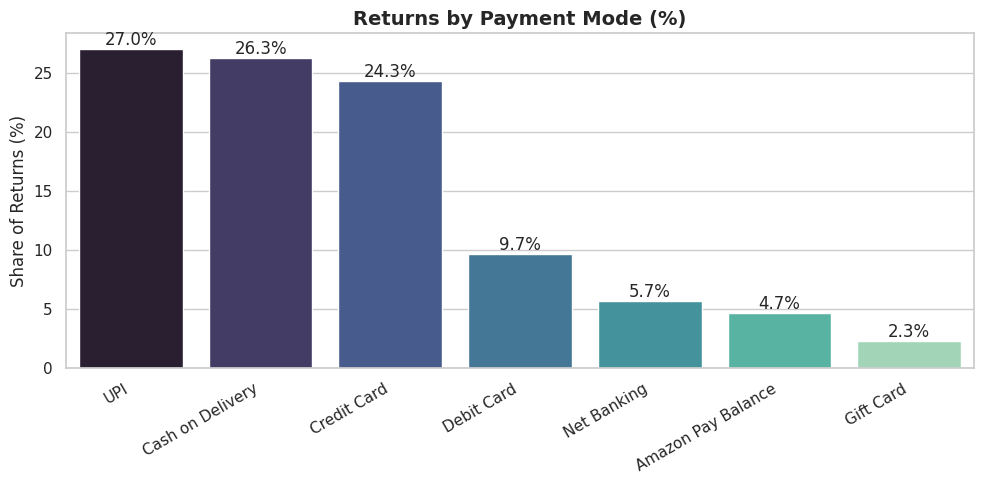

In [ ]:
# CHART 6: Payment Mode  (Bar chart, with percentages)
# WHAT IT SHOWS: share of returns by how the customer paid.
# WHY IT'S USEFUL: Cash on Delivery orders often show higher return rates.
pay = df["Payment_Mode"].value_counts(normalize=True).mul(100).round(1)
ax = sns.barplot(x=pay.index, y=pay.values, hue=pay.index, palette="mako", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.title("Returns by Payment Mode (%)")
plt.xlabel("")
plt.ylabel("Share of Returns (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


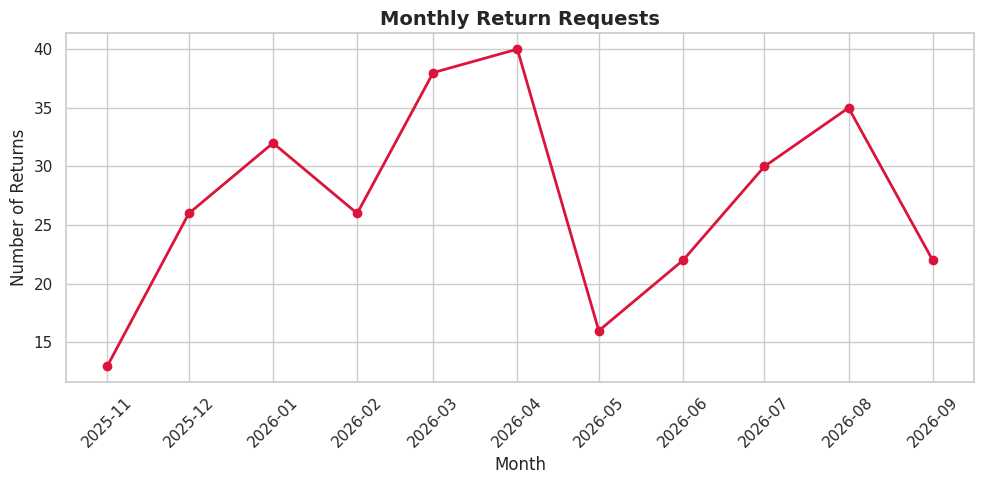

In [ ]:
# CHART 7: Monthly Return Trend  (Line chart)
# WHAT IT SHOWS: how the number of returns changes month by month.
# WHY IT'S USEFUL: reveals seasonality (e.g. festive-season spikes).
monthly = (
    df.set_index("Return_Request_Date")
      .resample("MS")["Return_ID"]
      .count()
)
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="crimson")
plt.title("Monthly Return Requests")
plt.xlabel("Month")
plt.ylabel("Number of Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


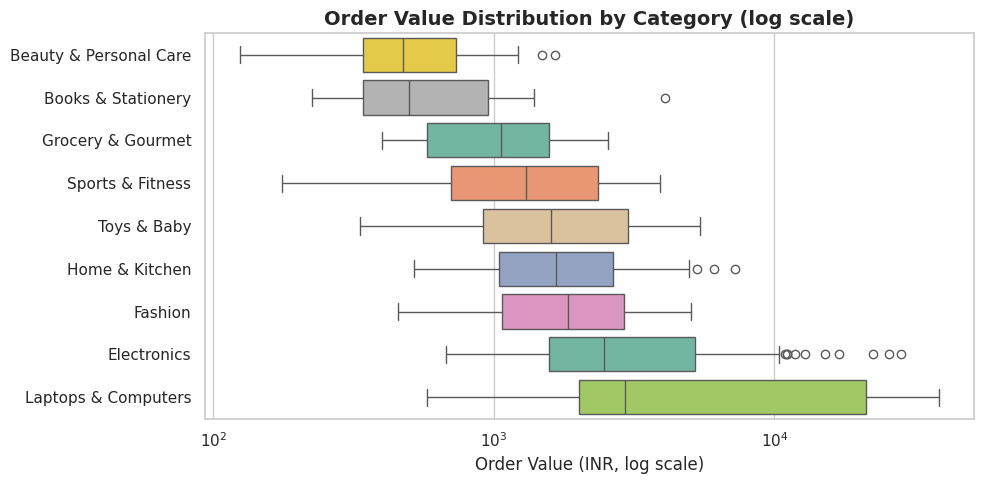

In [ ]:
# CHART 8: Order Value by Category  (Box plot)
# WHAT IT SHOWS: the spread of order values inside each category.
# HOW TO READ: the box = middle 50% of orders, the line inside = median,
# dots beyond the whiskers = unusually expensive orders (outliers).
# The log scale keeps cheap books and costly laptops readable together.
order = df.groupby("Category")["Order_Value_INR"].median().sort_values().index
sns.boxplot(data=df, x="Order_Value_INR", y="Category", order=order, hue="Category", palette="Set2", legend=False)
plt.xscale("log")
plt.title("Order Value Distribution by Category (log scale)")
plt.xlabel("Order Value (INR, log scale)")
plt.ylabel("")
plt.tight_layout()
plt.show()


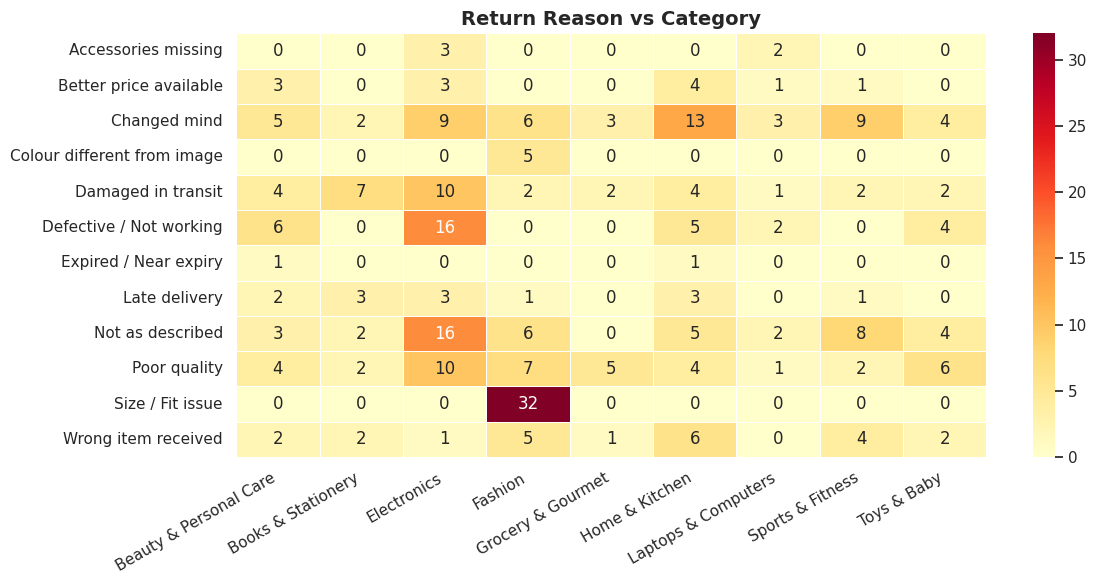

In [ ]:
# CHART 9: Return Reasons within each Category  (Heatmap)
# WHAT IT SHOWS: how often each reason occurs in each category.
# HOW TO READ: darker cells = more returns. Look for hot spots such as
# "Size / Fit issue" in Fashion or "Defective" in Electronics.
pivot = pd.crosstab(df["Return_Reason"], df["Category"])
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Return Reason vs Category")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


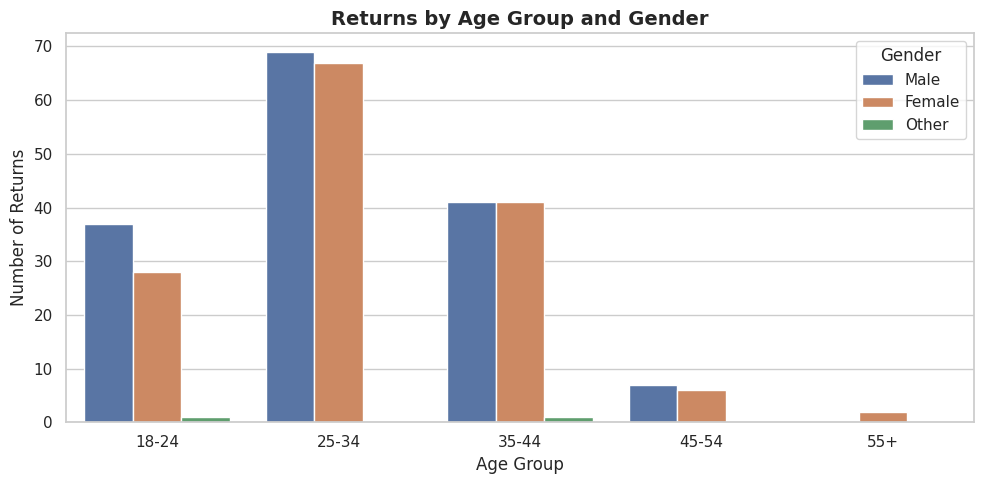

In [ ]:
# CHART 10: Age Group by Gender  (Grouped bar chart)
# WHAT IT SHOWS: returns for each age group, split by gender.
age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]
sns.countplot(data=df, x="Age_Group", hue="Gender", order=age_order)
plt.title("Returns by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Returns")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


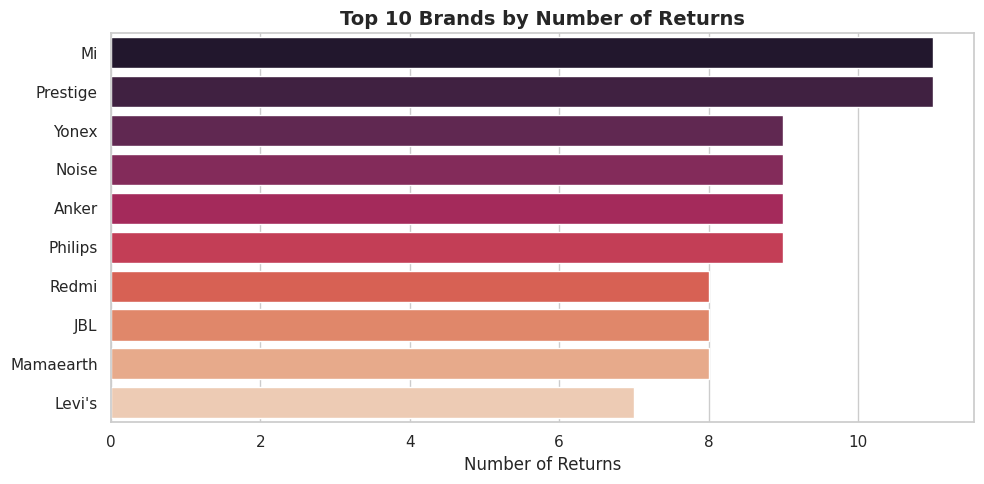

In [ ]:
# CHART 11: Top 10 Brands by Returns  (Horizontal bar chart)
# WHAT IT SHOWS: the brands with the most returned items.
top_brands = df["Brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette="rocket", legend=False)
plt.title("Top 10 Brands by Number of Returns")
plt.xlabel("Number of Returns")
plt.ylabel("")
plt.tight_layout()
plt.show()


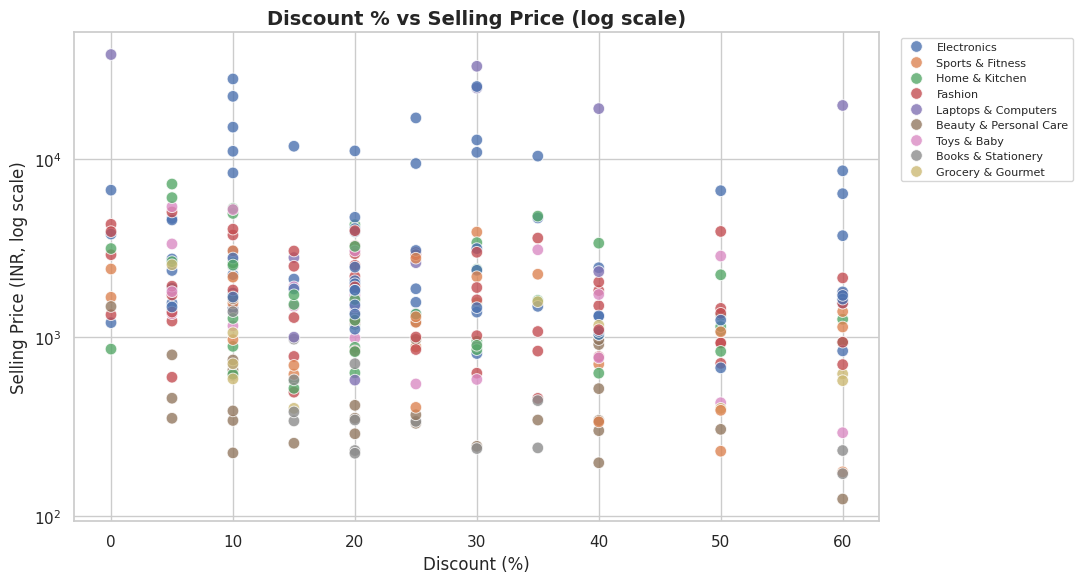

In [ ]:
# CHART 12: Discount vs Selling Price  (Scatter plot)
# WHAT IT SHOWS: each dot is one returned order.
# X = discount %, Y = selling price, colour = category.
# Used to spot whether heavily discounted items are returned more.
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x="Discount_Pct", y="Selling_Price_INR", hue="Category", alpha=0.8, s=70)
plt.yscale("log")
plt.title("Discount % vs Selling Price (log scale)")
plt.xlabel("Discount (%)")
plt.ylabel("Selling Price (INR, log scale)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


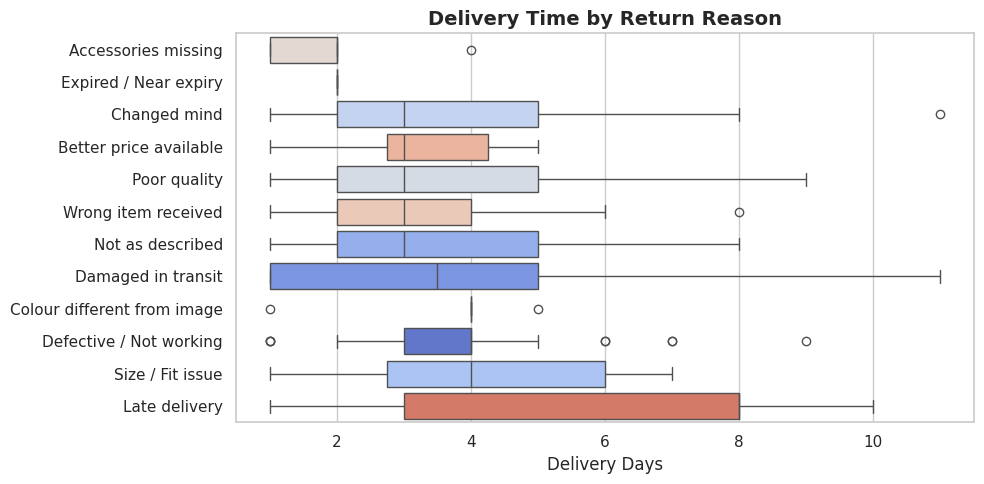

In [ ]:
# CHART 13: Delivery Days by Return Reason  (Box plot)
# WHAT IT SHOWS: do slow deliveries lead to "Late delivery" returns?
order = df.groupby("Return_Reason")["Delivery_Days"].median().sort_values().index
sns.boxplot(data=df, x="Delivery_Days", y="Return_Reason", order=order, hue="Return_Reason", palette="coolwarm", legend=False)
plt.title("Delivery Time by Return Reason")
plt.xlabel("Delivery Days")
plt.ylabel("")
plt.tight_layout()
plt.show()



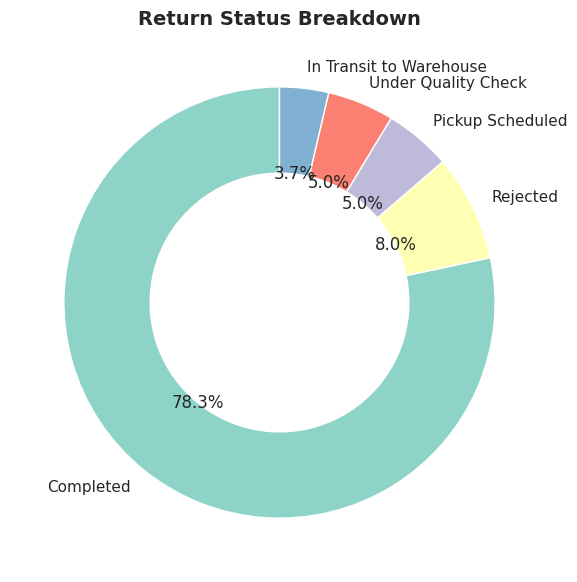

In [ ]:
# CHART 14: Return Status  (Donut chart)
# WHAT IT SHOWS: how many returns are completed, pending or rejected.
status = df["Return_Status"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3"),
    wedgeprops={"width": 0.4, "edgecolor": "white"},   # width < 1 makes it a donut
)
plt.title("Return Status Breakdown")
plt.show()


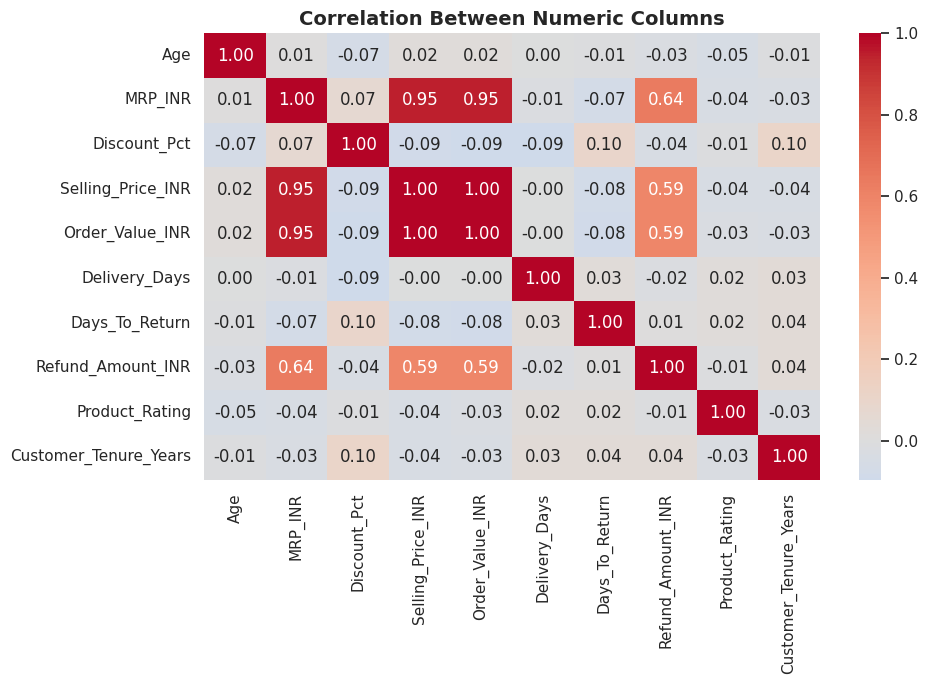

In [ ]:
# CHART 15: Correlation Heatmap  (Numeric columns)
# WHAT IT SHOWS: how strongly numeric columns move together.
# HOW TO READ: values near +1 = rise together, near -1 = move opposite,
# near 0 = no linear relationship.
num_cols = [
    "Age", "MRP_INR", "Discount_Pct", "Selling_Price_INR", "Order_Value_INR",
    "Delivery_Days", "Days_To_Return", "Refund_Amount_INR",
    "Product_Rating", "Customer_Tenure_Years",
]
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Columns")
plt.tight_layout()
plt.show()

